Caso 1: Telecomunicaciones CallMeMaybe
Objetivo: Identificar operadores ineficaces del servicio de telefonía virtual  

Paso 1 - Carga y exploración de datos


In [550]:
#importar librerías 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import zscore


In [551]:
# cargar datasets
clients = pd.read_csv(r'C:\Users\mateg\Documents\triple_ten\final_project_da\case1_telecom\data\raw\telecom_clients.csv')
telecom_new = pd.read_csv(r'C:\Users\mateg\Documents\triple_ten\final_project_da\case1_telecom\data\raw\telecom_dataset_new.csv')


1.1 Dataset clients - exploración

In [552]:
# Revisión de estructura, tipo de datos y valores ausentes
clients.shape

(732, 3)

In [553]:
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB


In [554]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


1.2 Dataset telecom_new - exploración

In [555]:
telecom_new.shape

(53902, 9)

In [556]:
telecom_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB


In [557]:
telecom_new.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [558]:
telecom_new.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


Paso 2 - Limpieza de datos

2.1 Manejo de valores nulos 

In [559]:

# Conversión de nulos y type de la columna 'internal' del DF 

telecom_new['internal'] = telecom_new['internal'].fillna(False).astype('bool')

In [560]:
# verificación de conversión de nulos
telecom_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53902 non-null  bool   
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(2), float64(1), int64(4), str(2)
memory usage: 3.0 MB


2.2 Correción del tipo de datos

In [561]:
# modificación de dtype de 'operator_id' a Int64
telecom_new['operator_id']=telecom_new['operator_id'].astype('Int64')

In [562]:
# modificación de dtype de 'date' a pd.to_datetime

telecom_new['date'] = pd.to_datetime(telecom_new['date'])

In [563]:
# modificación de dtype de 'date_start' a pd.to_datetime

clients['date_start'] = pd.to_datetime(clients['date_start'])

In [564]:
clients['tariff_plan']=clients['tariff_plan'].astype('category')

In [565]:
# Verificación de los anteriores cambios
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      732 non-null    int64         
 1   tariff_plan  732 non-null    category      
 2   date_start   732 non-null    datetime64[us]
dtypes: category(1), datetime64[us](1), int64(1)
memory usage: 12.3 KB


In [566]:
# verificación de los anteriores cambios
telecom_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                    
---  ------               --------------  -----                    
 0   user_id              53902 non-null  int64                    
 1   date                 53902 non-null  datetime64[us, UTC+03:00]
 2   direction            53902 non-null  str                      
 3   internal             53902 non-null  bool                     
 4   operator_id          45730 non-null  Int64                    
 5   is_missed_call       53902 non-null  bool                     
 6   calls_count          53902 non-null  int64                    
 7   call_duration        53902 non-null  int64                    
 8   total_call_duration  53902 non-null  int64                    
dtypes: Int64(1), bool(2), datetime64[us, UTC+03:00](1), int64(4), str(1)
memory usage: 3.0 MB


2.3 Verificación y eliminación de duplicados

In [567]:
# verificación de duplicados en dataset clients
clients.duplicated().sum()

np.int64(0)

In [568]:
# verificación de duplicados en dataset telecom_new
telecom_new.duplicated().sum()

np.int64(4900)

In [569]:
telecom_new[telecom_new.duplicated(keep=False)].head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
6,166377,2019-08-05 00:00:00+03:00,out,False,880020,True,8,0,50
8,166377,2019-08-05 00:00:00+03:00,out,False,880020,True,8,0,50
27,166377,2019-08-12 00:00:00+03:00,in,False,<NA>,True,2,0,34
28,166377,2019-08-12 00:00:00+03:00,in,False,<NA>,True,2,0,34
38,166377,2019-08-14 00:00:00+03:00,in,False,<NA>,True,1,0,3


In [570]:
telecom_new = telecom_new.drop_duplicates()

In [571]:
telecom_new.duplicated().sum()

np.int64(0)

Paso 3 - Integración de datos (MERGE)

In [572]:
# union de datasets
telecom_full = telecom_new.merge(clients, on='user_id', how='left')

In [573]:
# comprobación de número de filas
len(telecom_new), len(telecom_full)

(49002, 49002)

In [574]:
# comprobación de duplicados
clients['user_id'].duplicated().sum()

np.int64(0)

In [575]:
# verificación del merge()
telecom_full.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start
0,166377,2019-08-04 00:00:00+03:00,in,False,<NA>,True,2,0,4,B,2019-08-01
1,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,B,2019-08-01
3,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,B,2019-08-01
4,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,B,2019-08-01


In [576]:
# Compruebo el número total de usuarios únicos en todo el dataset

total_usuarios = telecom_full['operator_id'].nunique()
print("Número total de usuarios únicos:", total_usuarios)

Número total de usuarios únicos: 1092


Paso 4 - Análisis Exploratorio (EDA)

4.1 Distribuciones de variables clave

a. Análisis de: calls_count, call_duration, total_call_duration

In [577]:
# resumen descriptivo de las llamadas
telecom_full[['calls_count', 'call_duration', 'total_call_duration']].describe()

,calls_count,call_duration,total_call_duration
count,49002.000000,49002.000000,49002.000000
mean,16.462777,866.282091,1156.558202
std,63.604098,3775.503352,4451.473661
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,46.000000
50%,4.000000,37.000000,208.000000
75%,12.000000,570.000000,901.000000
max,4817.000000,144395.000000,166155.000000


Análisis de Variable call_duration (duración de llamdas) 

In [578]:
# call_duration:  convierto a minutos
telecom_full['call_duration_min'] = telecom_full['call_duration'] / 60

# total_call_duration:  convierto a minutos 
telecom_full['total_call_duration_min'] = telecom_full['total_call_duration'] / 60

In [579]:
# verifico el cambio de segundo a minutos 
telecom_full[['calls_count', 'call_duration_min', 'total_call_duration_min']].describe().round(0)

,calls_count,call_duration_min,total_call_duration_min
count,49002.0,49002.0,49002.0
mean,16.0,14.0,19.0
std,64.0,63.0,74.0
min,1.0,0.0,0.0
25%,1.0,0.0,1.0
50%,4.0,1.0,3.0
75%,12.0,10.0,15.0
max,4817.0,2407.0,2769.0


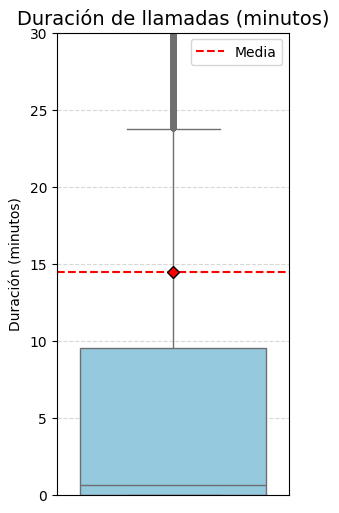

In [580]:
# análisis boxplot de la duración de llamdas(call_duration_min)--full

plt.figure(figsize=(3,6))

sns.boxplot(
    y='call_duration_min',
    data=telecom_full,
    color='skyblue',
    fliersize=3,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
        "markersize": 6
    }
)
mean_val = telecom_full['call_duration_min'].mean()
plt.axhline(mean_val, color='red', linestyle='--', label='Media')
plt.legend()

# Limitar eje Y para enfocarse en valores típicos
plt.ylim(0, 30)  

plt.title('Duración de llamadas (minutos)', fontsize=14)
plt.ylabel('Duración (minutos)')
plt.xticks([])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

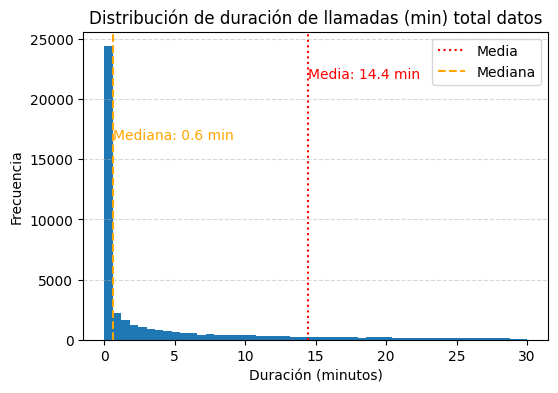

In [581]:
# Histograma de la variable de duración de llamadas -- full

plt.figure(figsize=(6,4))

# Histograma
plt.hist(
    telecom_full['call_duration_min'],
    bins=50,
    range=(0, 30),
)

# Calcular valores
mean_val = telecom_full['call_duration_min'].mean()
median_val = telecom_full['call_duration_min'].median()

# Líneas
plt.axvline(mean_val, color='red', linestyle=':', label='Media')
plt.axvline(median_val, color='orange', linestyle='--', label='Mediana')

# Etiquetas
plt.text(mean_val, plt.ylim()[1]*0.85, f'Media: {mean_val:.1f} min', color='red')
plt.text(median_val, plt.ylim()[1]*0.65, f'Mediana: {median_val:.1f} min', color='orange')

# Títulos
plt.title('Distribución de duración de llamadas (min) total datos')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [582]:
# Ahora separamos los típicos de outliers aplicando IQR en variable call_duration_min

# Calcular Q1, Q3 e IQR para call_duration_min
Q1 = telecom_full['call_duration_min'].quantile(0.25)
Q3 = telecom_full['call_duration_min'].quantile(0.75)
IQR = Q3 - Q1

# Límites según la regla IQR
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")

# Separar típicos y outliers
tipicos_duration = telecom_full[
    (telecom_full['call_duration_min'] >= lim_inf) &
    (telecom_full['call_duration_min'] <= lim_sup)
].copy()

outliers_duration = telecom_full[
    (telecom_full['call_duration_min'] < lim_inf) |
    (telecom_full['call_duration_min'] > lim_sup)
].copy()

print("Cantidad de típicos:", len(tipicos_duration))
print("Cantidad de outliers:", len(outliers_duration))

# Activar dataset principal 
tipicos = tipicos_duration.copy()
outliers = outliers_duration.copy()


Límite inferior: -14.25
Límite superior: 23.75
Cantidad de típicos: 42136
Cantidad de outliers: 6866


In [583]:
# redefino el nombre de las varibales con su conteo

n_tipicos_duration = len(tipicos_duration)
n_outliers_duration = len(outliers_duration)

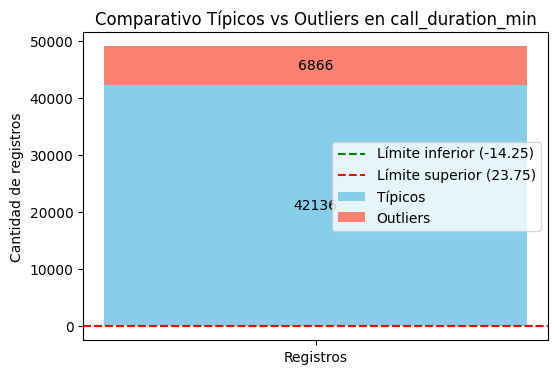

In [584]:

# Crear gráfico de barras para distribucion de tipicos y outliers en la variable Call_duration
fig, ax = plt.subplots(figsize=(6,4))

ax.bar("Registros", n_tipicos_duration, color="skyblue", label="Típicos")
ax.bar("Registros", n_outliers_duration, bottom=n_tipicos_duration, color="salmon", label="Outliers")

# Etiquetas
ax.text(0, n_tipicos_duration/2, str(n_tipicos_duration), ha="center", va="center", fontsize=10)
ax.text(0, n_tipicos_duration + n_outliers_duration/2, str(n_outliers_duration), ha="center", va="center", fontsize=10)

# Líneas IQR
ax.axhline(y=lim_inf, color="green", linestyle="--", label=f"Límite inferior ({lim_inf})")
ax.axhline(y=lim_sup, color="red", linestyle="--", label=f"Límite superior ({lim_sup})")

# Títulos
ax.set_title("Comparativo Típicos vs Outliers en call_duration_min")
ax.set_ylabel("Cantidad de registros")
ax.legend()

plt.show()

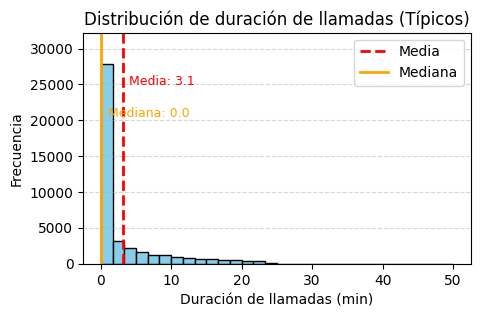

In [585]:
# Histograma de duración de llamadas (Típicos)

plt.figure(figsize=(5,3))

# Histograma
plt.hist(
    tipicos['call_duration_min'],  
    bins=30,
    range=(0, 50),
    color="skyblue",
    edgecolor="black"
)

# Calcular valores
mean_val = tipicos['call_duration_min'].mean()
median_val = tipicos['call_duration_min'].median()

# Líneas de referencia
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label='Media')
plt.axvline(median_val, color='orange', linestyle='-', linewidth=2, label='Mediana')

# Etiquetas bien posicionadas (sin que se monten)
for val, label, color, offset in [
    (mean_val, 'Media', 'red', 0.85),
    (median_val, 'Mediana', 'orange', 0.7)
]:
    plt.annotate(
        f'{label}: {val:.1f}',
        xy=(val, plt.ylim()[1]*offset),
        xytext=(5, 0),
        textcoords='offset points',
        color=color,
        fontsize=9
    )

# Espacio arriba
plt.ylim(0, plt.ylim()[1] * 1.1)

# Títulos
plt.title('Distribución de duración de llamadas (Típicos)')
plt.xlabel('Duración de llamadas (min)')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [586]:
# verificación de variable call_duration con y sin operador - Tipicos

# Separar los grupos
sin_operador_tipicos_duration = tipicos_duration[tipicos_duration['operator_id'].isnull()]
con_operador_tipicos_duration = tipicos_duration[tipicos_duration['operator_id'].notnull()]

# Cantidad de llamadas
cant_sin_operador = len(sin_operador_tipicos_duration)
cant_con_operador = len(con_operador_tipicos_duration)
total = len(tipicos_duration)

# Porcentaje de llamadas
pct_sin_operador = cant_sin_operador / total * 100
pct_con_operador = cant_con_operador / total * 100

# Mostrar resultados
print(f"Llamadas sin operador: {cant_sin_operador} ({pct_sin_operador:.2f}%)")
print(f"Llamadas con operador: {cant_con_operador} ({pct_con_operador:.2f}%)")

Llamadas sin operador: 7402 (17.57%)
Llamadas con operador: 34734 (82.43%)


C:\Users\mateg\AppData\Local\Temp\ipykernel_19592\2532960145.py:25: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


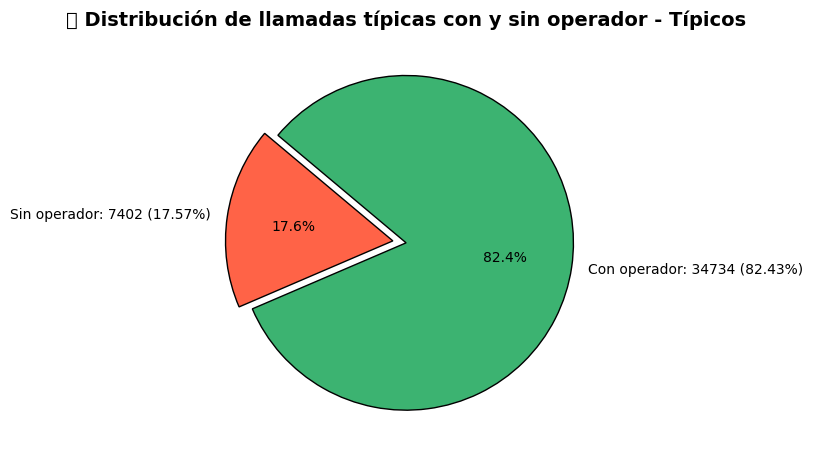

In [587]:
# llamadas con y sin operador en la variable call_duration - tipicos


import matplotlib.pyplot as plt

# Datos
labels = ['Sin operador', 'Con operador']
sizes = [7402, 34734]
percentages = [17.57, 82.43]
colors = ['tomato', 'mediumseagreen']
explode = (0.08, 0)  # destacar la porción de llamadas sin operador

# Gráfico de torta
plt.figure(figsize=(8,8))
plt.pie(
    sizes,
    labels=[f"{labels[i]}: {sizes[i]} ({percentages[i]}%)" for i in range(len(labels))],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    wedgeprops={'edgecolor':'black', 'linewidth':1}
)
plt.title("📊 Distribución de llamadas típicas con y sin operador - Típicos", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Análisis de la variable calls_count

In [588]:
# Estadísticas descriptivas del total de datos call_count -- full
calls_count_stats = telecom_full['calls_count'].describe()
calls_count_stats

count    49002.000000
mean        16.462777
std         63.604098
min          1.000000
25%          1.000000
50%          4.000000
75%         12.000000
max       4817.000000
Name: calls_count, dtype: float64

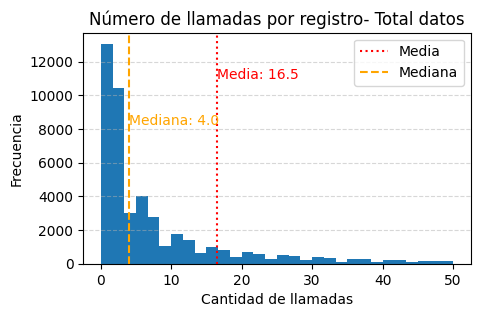

In [589]:
# Histograma de número de llamadas por registro- full

plt.figure(figsize=(5,3))

# Histograma
plt.hist(
    telecom_full['calls_count'],
    bins=30,
    range=(0, 50)
)

# Calcular valores
mean_val = telecom_full['calls_count'].mean()
median_val = telecom_full['calls_count'].median()

# Líneas
plt.axvline(mean_val, color='red', linestyle=':', label='Media')
plt.axvline(median_val, color='orange', linestyle='--', label='Mediana')

# Etiquetas (texto en el gráfico)
plt.text(mean_val, plt.ylim()[1]*0.8, f'Media: {mean_val:.1f}', color='red')
plt.text(median_val, plt.ylim()[1]*0.6, f'Mediana: {median_val:.1f}', color='orange')

# Títulos
plt.title('Número de llamadas por registro- Total datos')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

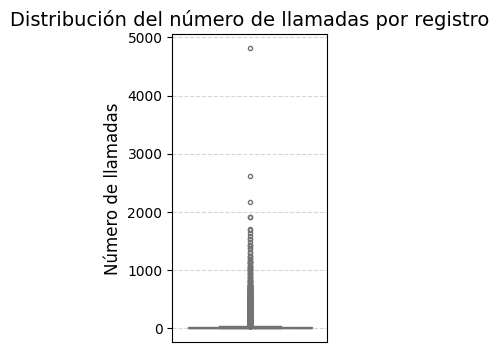

In [590]:
# boxplot del número de llamadas por registro -- full

plt.figure(figsize=(2,4))
sns.boxplot(
    y='calls_count', 
    data=telecom_full, 
    color='lightgreen',
    fliersize=3
)
plt.title('Distribución del número de llamadas por registro', fontsize=14)
plt.ylabel('Número de llamadas', fontsize=12)
plt.xticks([])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [591]:
# Separación de típicos de outliers de variable call_count (IQR)

# Calcular Q1, Q3 e IQR para calls_count
Q1 = telecom_full['calls_count'].quantile(0.25)
Q3 = telecom_full['calls_count'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")

# Separar típicos y outliers
tipicos_calls = telecom_full[
    (telecom_full['calls_count'] >= lim_inf) &
    (telecom_full['calls_count'] <= lim_sup)
].copy()

outliers_calls = telecom_full[
    (telecom_full['calls_count'] < lim_inf) |
    (telecom_full['calls_count'] > lim_sup)
].copy()

print("Cantidad de típicos:", len(tipicos_calls))
print("Cantidad de outliers:", len(outliers_calls))

Límite inferior: -15.50
Límite superior: 28.50
Cantidad de típicos: 42955
Cantidad de outliers: 6047


In [592]:
# redefino nombre de variable para calls_count tipicos y outliers

n_tipicos_calls = len(tipicos_calls)
n_outliers_calls = len(outliers_calls)

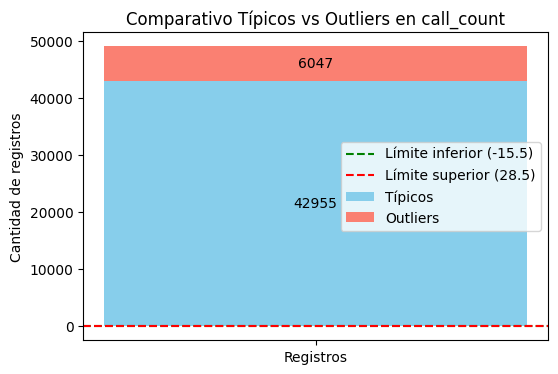

In [593]:
# Comparativo de tipicos vs outliers en call_count

n_tipicos_calls = len(tipicos_calls)
n_outliers_calls = len(outliers_calls)

# Límites IQR (ya los tienes calculados arriba)
# lim_inf y lim_sup

# Crear gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(6,4))

ax.bar("Registros", n_tipicos_calls, color="skyblue", label="Típicos")
ax.bar("Registros", n_outliers_calls, bottom=n_tipicos_calls, color="salmon", label="Outliers")

# Etiquetas
ax.text(0, n_tipicos_calls/2, str(n_tipicos_calls), ha="center", va="center", fontsize=10)
ax.text(0, n_tipicos_calls + n_outliers_calls/2, str(n_outliers_calls), ha="center", va="center", fontsize=10)

# Líneas IQR
ax.axhline(y=lim_inf, color="green", linestyle="--", label=f"Límite inferior ({lim_inf})")
ax.axhline(y=lim_sup, color="red", linestyle="--", label=f"Límite superior ({lim_sup})")

# Títulos
ax.set_title("Comparativo Típicos vs Outliers en call_count")
ax.set_ylabel("Cantidad de registros")
ax.legend()

plt.show()

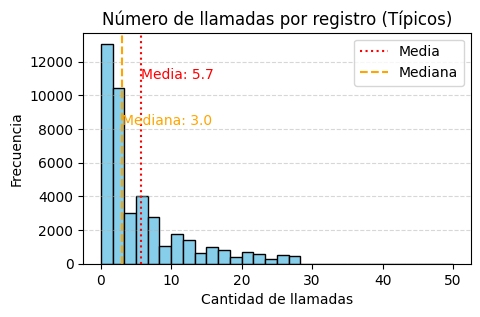

In [594]:
# gráfico histograma de los típicos call_count


plt.figure(figsize=(5,3))

# Histograma de los típicos
plt.hist(
    tipicos_calls['calls_count'],
    bins=30,
    range=(0, 50),
    color="skyblue",
    edgecolor="black"
)

# Calcular valores
mean_val = tipicos_calls['calls_count'].mean()
median_val = tipicos_calls['calls_count'].median()

# Líneas de referencia
plt.axvline(mean_val, color='red', linestyle=':', label='Media')
plt.axvline(median_val, color='orange', linestyle='--', label='Mediana')

# Etiquetas en el gráfico
plt.text(mean_val, plt.ylim()[1]*0.8, f'Media: {mean_val:.1f}', color='red')
plt.text(median_val, plt.ylim()[1]*0.6, f'Mediana: {median_val:.1f}', color='orange')

# Títulos y ejes
plt.title('Número de llamadas por registro (Típicos)')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Análisis de variable total_call_duration (duración total de llamdas por registro)

In [595]:
# Estadísticas descriptivas de duración total de llamadas por registro
total_call_stats = telecom_full['total_call_duration_min'].describe()
total_call_stats

count    49002.000000
mean        19.275970
std         74.191228
min          0.000000
25%          0.766667
50%          3.466667
75%         15.016667
max       2769.250000
Name: total_call_duration_min, dtype: float64

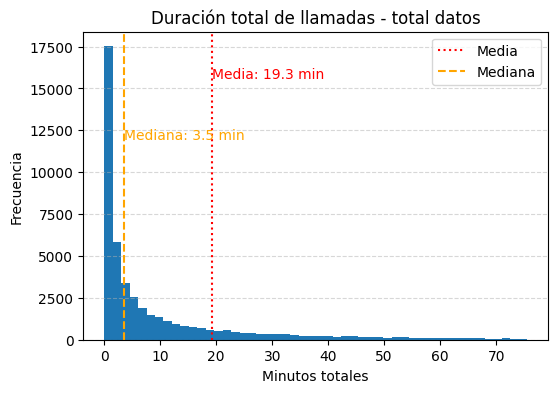

In [596]:
# Histograma de la duración total de llamadas -- full

plt.figure(figsize=(6,4))

#  límite inteligente
limit = telecom_full['total_call_duration_min'].quantile(0.95)

# Histograma
plt.hist(
    telecom_full['total_call_duration_min'],
    bins=50,
    range=(0, limit)
)

# Media y mediana
mean_val = telecom_full['total_call_duration_min'].mean()
median_val = telecom_full['total_call_duration_min'].median()

plt.axvline(mean_val, color='red', linestyle=':', label='Media')
plt.axvline(median_val, color='orange', linestyle='--', label='Mediana')

# Etiquetas
plt.text(mean_val, plt.ylim()[1]*0.85, f'Media: {mean_val:.1f} min', color='red')
plt.text(median_val, plt.ylim()[1]*0.65, f'Mediana: {median_val:.1f} min', color='orange')

# Títulos
plt.title('Duración total de llamadas - total datos')
plt.xlabel('Minutos totales')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [597]:
# Separación de típicos vs outliers 

# Calcular Q1, Q3 e IQR para total_call_duration_min
Q1 = telecom_full['total_call_duration_min'].quantile(0.25)
Q3 = telecom_full['total_call_duration_min'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")

# Separar típicos y outliers
tipicos_total = telecom_full[
    (telecom_full['total_call_duration_min'] >= lim_inf) &
    (telecom_full['total_call_duration_min'] <= lim_sup)
].copy()

outliers_total = telecom_full[
    (telecom_full['total_call_duration_min'] < lim_inf) |
    (telecom_full['total_call_duration_min'] > lim_sup)
].copy()

print("Cantidad de típicos:", len(tipicos_total))
print("Cantidad de outliers:", len(outliers_total))

Límite inferior: -20.61
Límite superior: 36.39
Cantidad de típicos: 43070
Cantidad de outliers: 5932


In [598]:
# redefino nombre de variables tipicos y outliers en total_call_count
n_tipicos_total = len(tipicos_total)
n_outliers_total = len(outliers_total)

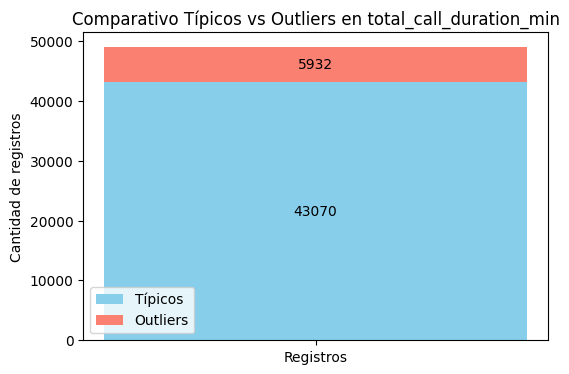

In [599]:
# Comparativo tipicos vs outliers en variable total_call_duration_min


fig, ax = plt.subplots(figsize=(6,4))

ax.bar(["Registros"], [n_tipicos_total], color="skyblue", label="Típicos")
ax.bar(["Registros"], [n_outliers_total], bottom=[n_tipicos_total], color="salmon", label="Outliers")

# Etiquetas
ax.text(0, n_tipicos_total/2, str(n_tipicos_total), ha="center", va="center", fontsize=10)
ax.text(0, n_tipicos_total + n_outliers_total/2, str(n_outliers_total), ha="center", va="center", fontsize=10)

ax.set_title("Comparativo Típicos vs Outliers en total_call_duration_min")
ax.set_ylabel("Cantidad de registros")
ax.legend()

plt.show()

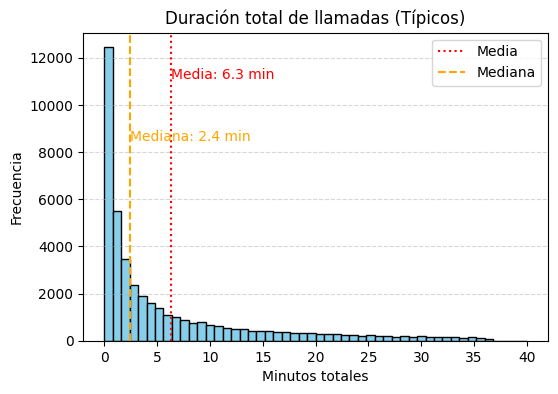

In [600]:
# Histograma de los típicos de la variable duración total 

plt.figure(figsize=(6,4))

# Histograma de los típicos
plt.hist(
    tipicos_total['total_call_duration_min'],
    bins=50,
    range=(0, 40),   # rango ajustado al límite superior típico (36.39 aprox.)
    color="skyblue",
    edgecolor="black"
)

# Media y mediana de los típicos
mean_val = tipicos_total['total_call_duration_min'].mean()
median_val = tipicos_total['total_call_duration_min'].median()

# Líneas de referencia
plt.axvline(mean_val, color='red', linestyle=':', label='Media')
plt.axvline(median_val, color='orange', linestyle='--', label='Mediana')

# Etiquetas en el gráfico
plt.text(mean_val, plt.ylim()[1]*0.85, f'Media: {mean_val:.1f} min', color='red')
plt.text(median_val, plt.ylim()[1]*0.65, f'Mediana: {median_val:.1f} min', color='orange')

# Títulos y ejes
plt.title('Duración total de llamadas (Típicos)')
plt.xlabel('Minutos totales')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Análisis de Tiempos de Espera en las llamdas

In [601]:
# Calcular wait_time **sobre los típicos**
tipicos['wait_time'] = tipicos['total_call_duration_min'] - tipicos['call_duration_min']

# Revisar algunos registros
tipicos[['call_duration_min', 'total_call_duration_min', 'wait_time']].head()

,call_duration_min,total_call_duration_min,wait_time
0,0.000000,0.066667,0.066667
1,0.000000,0.083333,0.083333
2,0.000000,0.016667,0.016667
3,0.166667,0.300000,0.133333
4,0.000000,0.416667,0.416667


In [602]:
# Mostrar los primeros 5 registros con mayor wait_time - tipicos
tipicos[['wait_time', 'operator_id', 'call_duration_min', 'total_call_duration_min']].sort_values(
    by='wait_time',
    ascending=False
).head()

,wait_time,operator_id,call_duration_min,total_call_duration_min
36993,755.200000,929428,0.0,755.200000
46290,711.116667,<NA>,0.0,711.116667
46242,704.183333,<NA>,0.0,704.183333
6359,558.966667,885876,0.0,558.966667
6307,556.116667,885876,0.0,556.116667


In [603]:
# Llamadas sin operador en el grupo de los típicos
sin_operador_tipicos = tipicos[tipicos['operator_id'].isnull()]

# Llamadas con operador
con_operador_tipicos = tipicos[tipicos['operator_id'].notnull()]

In [604]:
# Promedio de espera en llamadas sin y con operador - Típicos
prom_sin_operador_tipicos = sin_operador_tipicos['wait_time'].mean()

# Promedio de espera en llamadas con operador
prom_con_operador_tipicos = con_operador_tipicos['wait_time'].mean()

print(f"Promedio tiempo de espera sin operador (tipicos): {prom_sin_operador_tipicos:.2f} min")
print(f"Promedio tiempo de espera con operador (tipicos): {prom_con_operador_tipicos:.2f} min")

Promedio tiempo de espera sin operador (tipicos): 2.84 min
Promedio tiempo de espera con operador (tipicos): 3.69 min


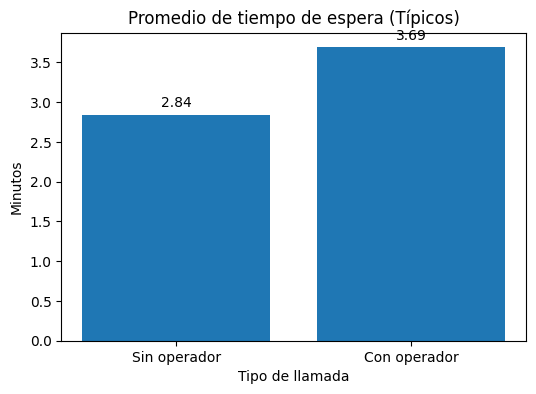

In [605]:
# Gráfico de tiempos de espera en los típicos con y sin operador

# Valores
labels = ['Sin operador', 'Con operador']
valores = [prom_sin_operador_tipicos, prom_con_operador_tipicos]

# Crear gráfico
plt.figure(figsize=(6,4))
plt.bar(labels, valores)

# Agregar valores encima de las barras
for i, v in enumerate(valores):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center')

# Títulos
plt.title("Promedio de tiempo de espera (Típicos)")
plt.ylabel("Minutos")
plt.xlabel("Tipo de llamada")

plt.show()

Aclaración sobre NA en la columna operator_id

En el info incial del dataset telecom_new, habían sido detectados 8172 nulos en ('operator_id') que fueron dejados tal cual, sin modificación para no alterar posibles análisis. Estos nulos, fueron traducidos como llamadas sin operador y empezaron a tomar relevancia, especialmente cuando calculamos wait_time, identificando casos (outliers) de más de 700 minutos de espera, correspondientes a llamadas sin operador. 

In [606]:
# calcular Llamadas con y sin operador en dataset full

sin_operador = telecom_full[telecom_full['operator_id'].isnull()]

# Llamadas con operador
con_operador = telecom_full[telecom_full['operator_id'].notnull()]

In [607]:
# obtener participación de llamdas con y sin operador - en full 

# Total de llamadas
total_llamadas = len(telecom_full)

# Grupo sin operador
cantidad_sin = len(sin_operador)
porcentaje_sin = (cantidad_sin / total_llamadas) * 100

# Grupo con operador
cantidad_con = len(con_operador)
porcentaje_con = (cantidad_con / total_llamadas) * 100

print(f"Llamadas sin operador: {cantidad_sin} ({porcentaje_sin:.2f}%)")
print(f"Llamadas con operador: {cantidad_con} ({porcentaje_con:.2f}%)")

Llamadas sin operador: 7456 (15.22%)
Llamadas con operador: 41546 (84.78%)


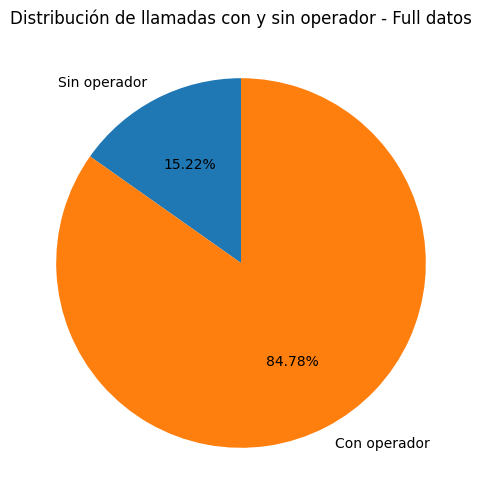

In [608]:
# Gráfico de participación de llamdas con y sin operador -full
# Datos
labels = ['Sin operador', 'Con operador']
sizes = [7456, 41546]

# Gráfico
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90)

plt.title("Distribución de llamadas con y sin operador - Full datos")
plt.show()

In [609]:
# Calcular wait_time sobre telecom_full
telecom_full['wait_time'] = telecom_full['total_call_duration_min'] - telecom_full['call_duration_min']

# Revisar algunos registros
telecom_full[['call_duration_min', 'total_call_duration_min', 'wait_time']].head()

,call_duration_min,total_call_duration_min,wait_time
0,0.000000,0.066667,0.066667
1,0.000000,0.083333,0.083333
2,0.000000,0.016667,0.016667
3,0.166667,0.300000,0.133333
4,0.000000,0.416667,0.416667


In [610]:
# Crear la columna wait_time en telecom_full
telecom_full['wait_time'] = telecom_full['total_call_duration_min'] - telecom_full['call_duration_min']

# Volver a separar los grupos ahora que wait_time existe
sin_operador = telecom_full[telecom_full['operator_id'].isnull()]
con_operador = telecom_full[telecom_full['operator_id'].notnull()]

# Promedio de espera
prom_sin_operador = sin_operador['wait_time'].mean()
prom_con_operador = con_operador['wait_time'].mean()

print(f"Promedio tiempo de espera sin operador: {prom_sin_operador:.2f} min")
print(f"Promedio tiempo de espera con operador: {prom_con_operador:.2f} min")

Promedio tiempo de espera sin operador: 2.84 min
Promedio tiempo de espera con operador: 5.20 min


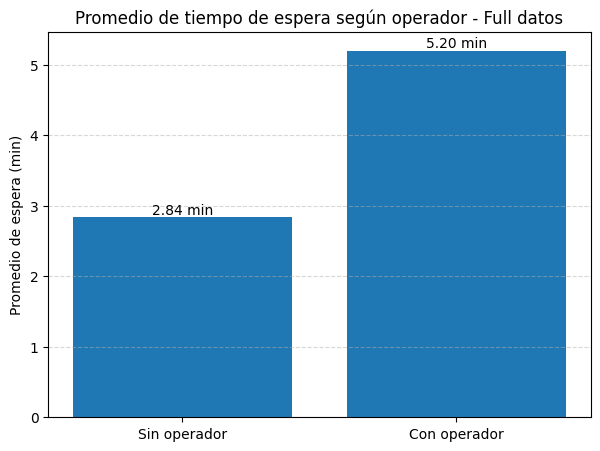

In [611]:
# promedio de tiempos de espera con y sin operador - Full

# Datos
promedios = [prom_sin_operador, prom_con_operador]
categorias = ['Sin operador', 'Con operador']

# Crear gráfico
plt.figure(figsize=(7,5))
bars = plt.bar(categorias, promedios)

# Agregar etiquetas encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f} min",
        ha='center',
        va='bottom',
        fontsize=10
    )

# Estética
plt.ylabel('Promedio de espera (min)')
plt.title('Promedio de tiempo de espera según operador - Full datos')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [612]:
# Intersección de típicos: solo los registros típicos en las tres variables
tipicos = telecom_full.loc[
    telecom_full.index.isin(tipicos_duration.index) &
    telecom_full.index.isin(tipicos_calls.index) &
    telecom_full.index.isin(tipicos_total.index)
].copy()

print("Cantidad de registros típicos en las tres variables:", len(tipicos))
tipicos.head()

Cantidad de registros típicos en las tres variables: 39289


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start,call_duration_min,total_call_duration_min,wait_time
0,166377,2019-08-04 00:00:00+03:00,in,False,<NA>,True,2,0,4,B,2019-08-01,0.000000,0.066667,0.066667
1,166377,2019-08-05 00:00:00+03:00,out,True,880022,True,3,0,5,B,2019-08-01,0.000000,0.083333,0.083333
2,166377,2019-08-05 00:00:00+03:00,out,True,880020,True,1,0,1,B,2019-08-01,0.000000,0.016667,0.016667
3,166377,2019-08-05 00:00:00+03:00,out,True,880020,False,1,10,18,B,2019-08-01,0.166667,0.300000,0.133333
4,166377,2019-08-05 00:00:00+03:00,out,False,880022,True,3,0,25,B,2019-08-01,0.000000,0.416667,0.416667


In [613]:
# Intersección de outliers: solo los registros outliers en las tres variables
outliers_interseccion = telecom_full.loc[
    telecom_full.index.isin(outliers_duration.index) &
    telecom_full.index.isin(outliers_calls.index) &
    telecom_full.index.isin(outliers_total.index)
].copy()

print("Cantidad de outliers en las 3 variables:", len(outliers_interseccion))
outliers_interseccion.head()

Cantidad de outliers en las 3 variables: 3097


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,tariff_plan,date_start,call_duration_min,total_call_duration_min,wait_time
57,166377,2019-08-20 00:00:00+03:00,out,False,880028,False,32,2975,3243,B,2019-08-01,49.583333,54.050000,4.466667
77,166377,2019-08-23 00:00:00+03:00,out,False,880026,False,43,3435,3654,B,2019-08-01,57.250000,60.900000,3.650000
159,166377,2019-09-10 00:00:00+03:00,out,False,880028,False,29,2082,2256,B,2019-08-01,34.700000,37.600000,2.900000
160,166377,2019-09-10 00:00:00+03:00,out,False,880026,False,32,2451,2620,B,2019-08-01,40.850000,43.666667,2.816667
190,166377,2019-09-16 00:00:00+03:00,out,False,880026,False,31,2587,2797,B,2019-08-01,43.116667,46.616667,3.500000


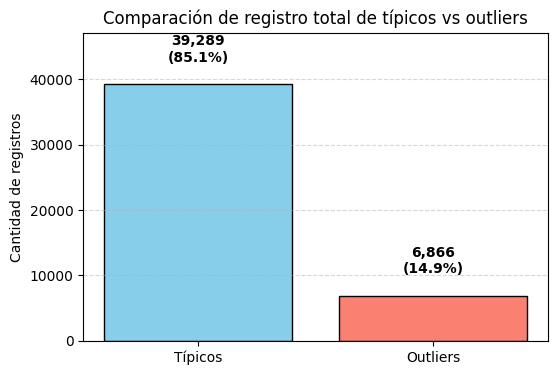

In [614]:
# Gráfico de Separación de típicos y outliers
# Cantidades
tipicos_count = len(tipicos)
outliers_count = len(outliers)

total = tipicos_count + outliers_count

# Datos para la gráfica
categorias = ['Típicos', 'Outliers']
valores = [tipicos_count, outliers_count]
colores = ['skyblue', 'salmon']

plt.figure(figsize=(6,4))

# Gráfico de barras
bars = plt.bar(categorias, valores, color=colores, edgecolor='black')

# Etiquetas encima de cada barra (con porcentaje)
for bar, valor in zip(bars, valores):
    porcentaje = valor / total * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3000,
        f'{valor:,}\n({porcentaje:.1f}%)',  # 👈 aquí agregas el %
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

# Títulos y ejes
plt.title('Comparación de registro total de típicos vs outliers')
plt.ylabel('Cantidad de registros')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(valores) * 1.2)
plt.show()

In [615]:
# Cantidad de outliers con y sin operador

# Separar outliers con y sin operador usando solo los de la intersección
outliers_sin_operador = outliers[outliers['operator_id'].isnull()]
outliers_con_operador = outliers[outliers['operator_id'].notnull()]

# Cantidades
cantidad_sin_operador = len(outliers_sin_operador)
cantidad_con_operador = len(outliers_con_operador)
total_outliers = len(outliers)

# Porcentajes
porcentaje_sin_operador = (cantidad_sin_operador / total_outliers) * 100
porcentaje_con_operador = (cantidad_con_operador / total_outliers) * 100

print(f"Outliers sin operador: {cantidad_sin_operador} ({porcentaje_sin_operador:.2f}%)")
print(f"Outliers con operador: {cantidad_con_operador} ({porcentaje_con_operador:.2f}%)")

Outliers sin operador: 54 (0.79%)
Outliers con operador: 6812 (99.21%)


In [616]:
# Contar outliers por dirección
conteo_direccion = outliers['direction'].value_counts()
porcentaje_direccion = (conteo_direccion / len(outliers)) * 100

print(conteo_direccion)
print(porcentaje_direccion)

direction
out    4983
in     1883
Name: count, dtype: int64
direction
out    72.575007
in     27.424993
Name: count, dtype: float64


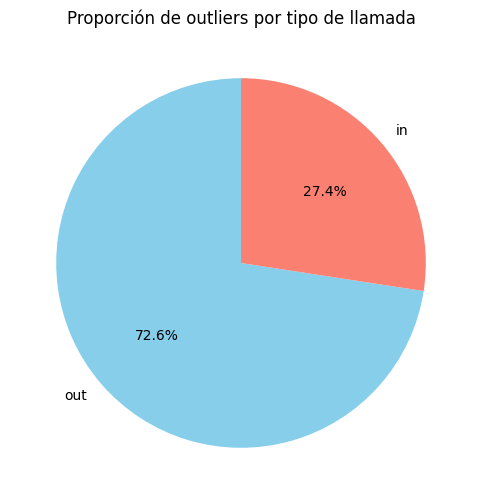

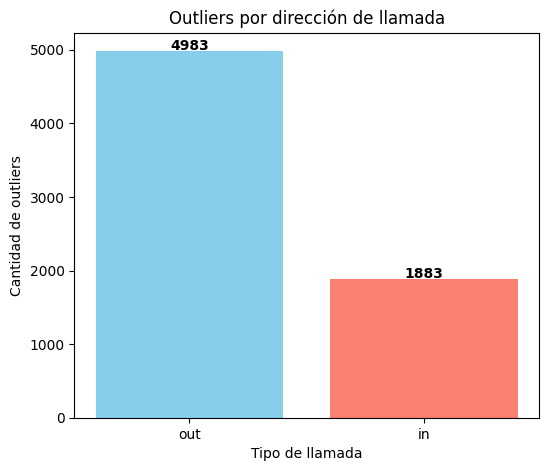

In [617]:
# Conteo y porcentajes de outliers por direccion de llamada

conteo_direccion = outliers['direction'].value_counts()
porcentaje_direccion = (conteo_direccion / len(outliers)) * 100

# Gráfico de torta
plt.figure(figsize=(6,6))
plt.pie(conteo_direccion, labels=conteo_direccion.index, autopct='%1.1f%%', colors=['skyblue','salmon'], startangle=90)
plt.title('Proporción de outliers por tipo de llamada')
plt.show()

# Gráfico de barras
plt.figure(figsize=(6,5))
plt.bar(conteo_direccion.index, conteo_direccion.values, color=['skyblue','salmon'])
plt.ylabel('Cantidad de outliers')
plt.xlabel('Tipo de llamada')
plt.title('Outliers por dirección de llamada')
for i, v in enumerate(conteo_direccion.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.show()

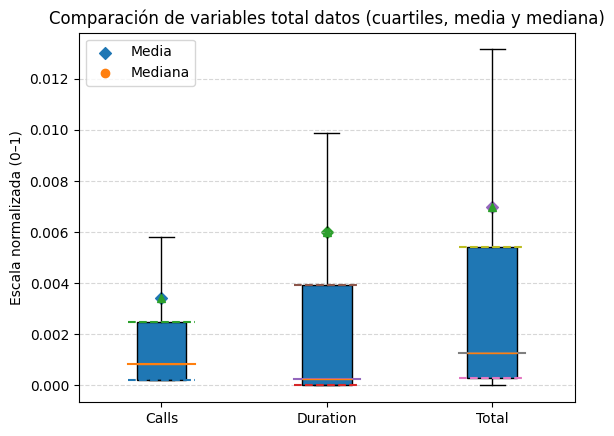

In [618]:
# Gráfico inicialmente comparativo de comportamiento de las 3 variables -full(incluyendo outliers)

#plt.figure(figsize=(6,5))

#  Normalizar variables
calls_norm = telecom_full['calls_count'] / telecom_full['calls_count'].max()
dur_norm = telecom_full['call_duration_min'] / telecom_full['call_duration_min'].max()
total_norm = telecom_full['total_call_duration_min'] / telecom_full['total_call_duration_min'].max()

data = [calls_norm, dur_norm, total_norm]
labels = ['Calls', 'Duration', 'Total']

# Boxplot
plt.boxplot(
    data,
    patch_artist=True,
    showmeans=True,
    showfliers=False
)

# Cuartiles + media + mediana
for i, var in enumerate(data):
    Q1 = var.quantile(0.25)
    Q2 = var.quantile(0.50)
    Q3 = var.quantile(0.75)
    mean = var.mean()
    
    # Cuartiles
    plt.plot([i+0.8, i+1.2], [Q1, Q1], linestyle='--')
    plt.plot([i+0.8, i+1.2], [Q2, Q2], linestyle='-')
    plt.plot([i+0.8, i+1.2], [Q3, Q3], linestyle='--')
    
    # 🔴 Media (solo una vez en la leyenda)
    plt.scatter(i+1, mean, marker='D', label='Media' if i == 0 else "")
    
    # 🟧 Mediana (AGREGAR ESTO)
    plt.scatter(i+1, Q2, marker='o', label='Mediana' if i == 0 else "")

# Etiquetas
plt.xticks([1,2,3], labels)
plt.title('Comparación de variables total datos (cuartiles, media y mediana)')
plt.ylabel('Escala normalizada (0–1)')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

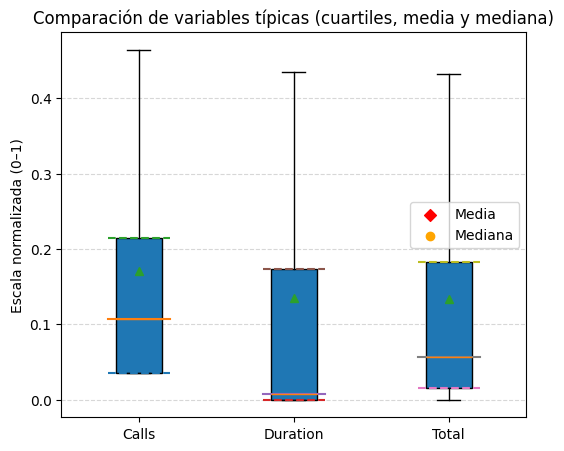

In [619]:
# grafico ahora las 3 variables con los típicos unicamente

plt.figure(figsize=(6,5))

# Normalizar variables en el df tipicos
calls_norm = tipicos['calls_count'] / tipicos['calls_count'].max()
dur_norm = tipicos['call_duration_min'] / tipicos['call_duration_min'].max()
total_norm = tipicos['total_call_duration_min'] / tipicos['total_call_duration_min'].max()

data = [calls_norm, dur_norm, total_norm]
labels = ['Calls', 'Duration', 'Total']

# Boxplot
plt.boxplot(
    data,
    patch_artist=True,
    showmeans=True,
    showfliers=False
)

# Cuartiles + media + mediana
for i, var in enumerate(data):
    Q1 = var.quantile(0.25)
    Q2 = var.quantile(0.50)
    Q3 = var.quantile(0.75)
    mean = var.mean()
    
    # Cuartiles
    plt.plot([i+0.8, i+1.2], [Q1, Q1], linestyle='--')
    plt.plot([i+0.8, i+1.2], [Q2, Q2], linestyle='-')
    plt.plot([i+0.8, i+1.2], [Q3, Q3], linestyle='--')
    
    # 🔴 Media (solo una vez en la leyenda)
    plt.scatter(i+1, mean, marker='D', color='red', label='Media' if i == 0 else "")
    
    # 🟧 Mediana (solo una vez en la leyenda)
    plt.scatter(i+1, Q2, marker='o', color='orange', label='Mediana' if i == 0 else "")

# Etiquetas
plt.xticks([1,2,3], labels)
plt.title('Comparación de variables típicas (cuartiles, media y mediana)')
plt.ylabel('Escala normalizada (0–1)')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Típicos, cuantiles, umbrales, score, semáforo:

En adelate se trbajará principalmente con el conjunto de registros típicos, aunque la idea es más adelante, analizar outliers.

 Adicionalmente y con el fin de establecer unos umbrales (basados en IQR) que sirvan como base para iniciar el proceso de identificación de operariios ineficientes (apoyados en un score y semáforo), se verifican inicialmente los respectivos cuantiles del dataset(típicos)

In [620]:
# Verifico ahora los cuantiles -- típicos

q25_calls = tipicos['calls_count'].quantile(0.25)
q50_calls = tipicos['calls_count'].quantile(0.50)

q50_duration = tipicos['call_duration_min'].quantile(0.50)
q75_duration = tipicos['call_duration_min'].quantile(0.75)

q50_total = tipicos['total_call_duration_min'].quantile(0.50)
q75_total = tipicos['total_call_duration_min'].quantile(0.75)

q50_missed = tipicos['is_missed_call'].mean()

print(
    f"Quantiles (datos típicos):\n"
    
    f"q25_calls: {q25_calls:.2f}\n"
    f"q50_calls: {q50_calls:.2f}\n"
    
    f"q50_duration: {q50_duration:.2f}\n"
    f"q75_duration: {q75_duration:.2f}\n"
    
    f"q50_total: {q50_total:.2f}\n"
    f"q75_total: {q75_total:.2f}\n"

    f"q50_missed: {q50_missed:.2f}\n"
)

Quantiles (datos típicos):
q25_calls: 1.00
q50_calls: 3.00
q50_duration: 0.18
q75_duration: 4.13
q50_total: 1.97
q75_total: 6.30
q50_missed: 0.48



In [621]:
# Definición de umbrales para los típicos a partir de quantiles

umbrales_tipicos = {
    'calls_muy_bajo': int(q25_calls),
    'calls_bajo': int(q50_calls),
    'duration_alta': round(float(q50_duration), 2),
    'duration_muy_alta': round(float(q75_duration), 2),
    'total_alta': round(float(q50_total), 2),
    'total_muy_alta': round(float(q75_total), 2),
    'missed_promedio': round(float(q50_missed), 1)  # porcentaje promedio
}

tabla_umbrales = pd.DataFrame(
    list(umbrales_tipicos.items()),
    columns=['Umbral', 'Valor']
)

print(tabla_umbrales.to_string(index=False))

           Umbral  Valor
   calls_muy_bajo   1.00
       calls_bajo   3.00
    duration_alta   0.18
duration_muy_alta   4.13
       total_alta   1.97
   total_muy_alta   6.30
  missed_promedio   0.50


In [622]:
# construcción de score de calificación eficiencia y productividad

def score_fila(row):
    score = 0

    # Calls (bajo = malo)
    if row['calls_count'] <= umbrales_tipicos['calls_muy_bajo']:
        score += 2
    elif row['calls_count'] <= umbrales_tipicos['calls_bajo']:
        score += 1

    # Duración (alto = sospechoso)
    if row['call_duration_min'] > umbrales_tipicos['duration_muy_alta']:
        score += 2
    elif row['call_duration_min'] > umbrales_tipicos['duration_alta']:
        score += 1

    # Total (alto = sospechoso)
    if row['total_call_duration_min'] > umbrales_tipicos['total_muy_alta']:
        score += 2
    elif row['total_call_duration_min'] > umbrales_tipicos['total_alta']:
        score += 1

    # Missed calls (alto = malo)
    if row['is_missed_call'] >= 0.60:   
        score += 2
    elif row['is_missed_call'] >= 0.10: 
        score += 1

    # Wait time (aplica solo si hay operador)
    if pd.notnull(row['operator_id']):
        # Por ejemplo, penalizamos si wait_time > mediana de tipicos
        median_wait = tipicos['wait_time'].median()
        if row['wait_time'] > median_wait * 1.5:  # 50% más que la mediana
            score += 2
        elif row['wait_time'] > median_wait:
            score += 1

    return score

In [623]:
# construir resumen por operador -- típicos

# 1️⃣ Crear columna de score antes de agrupar
tipicos['ineff_score'] = tipicos.apply(score_fila, axis=1)

# 2️⃣ Ahora sí agrupar
operador_summary_tipicos = tipicos.groupby('operator_id').agg(
    ineff_score_mean=('ineff_score', 'mean'),
    ineff_score_median=('ineff_score', 'median'),
    missed_call_rate=('is_missed_call', 'mean'),
    avg_wait_time=('wait_time', 'mean'),
    total_calls=('operator_id', 'count'),
    total_duration=('total_call_duration_min', 'sum')
).reset_index()

In [624]:
# validación

print(operador_summary_tipicos['ineff_score_mean'].describe())

count    1081.000000
mean        4.030771
std         0.848500
min         1.000000
25%         3.466667
50%         4.000000
75%         4.604839
max         7.000000
Name: ineff_score_mean, dtype: float64


4.2 Análisis por tipo de llamada 

In [625]:
#a.  Tasa de llamadas perdidas por dirección de llamada(in / out)

# Tasa de llamadas perdidas por dirección en porcentaje
lost_rate_dir_pct = (tipicos.groupby('direction')['is_missed_call'].mean() * 100).round(2)

print("Tasa de llamadas perdidas por dirección (%):\n", lost_rate_dir_pct)

Tasa de llamadas perdidas por dirección (%):
 direction
in     41.90
out    52.77
Name: is_missed_call, dtype: float64


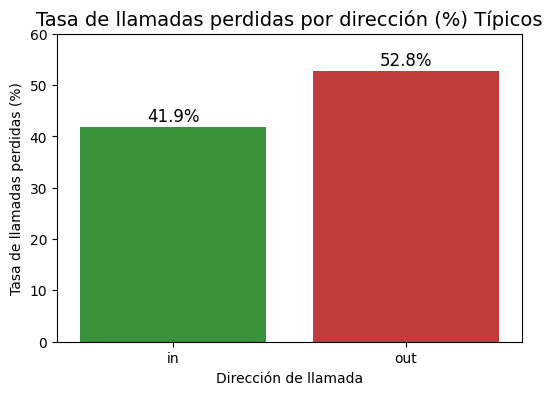

In [626]:

# Calcular la tasa de llamadas perdidas por dirección (%) - Típicos

lost_rate_dir_pct = (tipicos.groupby('direction')['is_missed_call'].mean() * 100).round(2)

# Preparar DataFrame para gráfico
df_missed = lost_rate_dir_pct.reset_index()
df_missed.columns = ['direction', 'missed']

# Crear figura
plt.figure(figsize=(6,4))
sns.barplot(
    data=df_missed,
    x='direction',
    y='missed',
    hue='direction',
    dodge=False,
    palette=['#2ca02c', '#d62728'],
    legend=False
)

# Títulos y ejes
plt.title("Tasa de llamadas perdidas por dirección (%) Típicos", fontsize=14)
plt.xlabel("Dirección de llamada")
plt.ylabel("Tasa de llamadas perdidas (%)" )
plt.ylim(0, 60)

# Mostrar valores encima de cada barra
for i, val in enumerate(df_missed['missed']):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontsize=12)

plt.show()

In [627]:
#b. Duración promedio por dirección de llamada Típicos
avg_time_dir = tipicos.groupby('direction')['call_duration_min'].median().round(2)
print("\nDuración promedio por dirección:\n", avg_time_dir)



Duración promedio por dirección:
 direction
in     0.57
out    0.00
Name: call_duration_min, dtype: float64


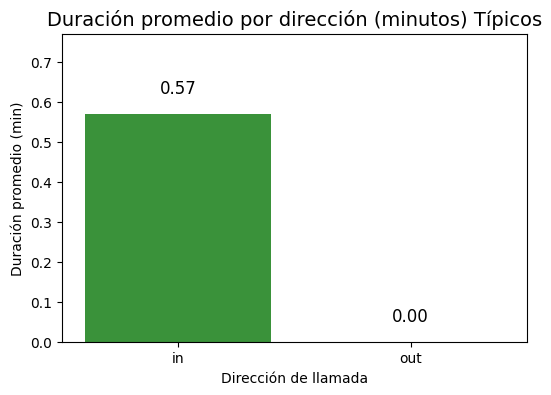

In [628]:
# Calcular duración promedio (mediana) por dirección sobre típicos

duration_avg = tipicos.groupby('direction')['call_duration_min'].median().round(2)

# Preparar DataFrame para gráfico
df_duration = duration_avg.reset_index()
df_duration.columns = ['direction', 'duration']

# Crear figura
plt.figure(figsize=(6,4))
sns.barplot(
    data=df_duration,
    x='direction',
    y='duration',
    hue='direction',
    dodge=False,
    palette=['#2ca02c', '#d62728'],
    legend=False
)

# Títulos y ejes
plt.title("Duración promedio por dirección (minutos) Típicos", fontsize=14)
plt.xlabel("Dirección de llamada")
plt.ylabel("Duración promedio (min)")
plt.ylim(0, max(df_duration['duration']) + 0.2)

# Mostrar valor encima de cada barra
for i, val in enumerate(df_duration['duration']):
    plt.text(i, val + 0.05, f"{val:.2f}", ha='center', fontsize=12)

plt.show()

#c. Tasa de llamadas perdidas - tipicos


In [629]:
# Calcular la tasa de llamadas perdidas según si hay operador o no

# Calcular la cantidad y total de llamadas perdidas según operador
perdidas_operador = tipicos.groupby(tipicos['operator_id'].notna())['is_missed_call'].agg(
    perdidas='sum',        
    total='count'
)

# Calcular porcentaje sobre el mismo DataFrame
perdidas_operador['%_perdidas'] = (perdidas_operador['perdidas'] / perdidas_operador['total'] * 100).round(2)

# Renombrar índices para etiquetas más amigables
perdidas_operador.index = ['Sin operador', 'Con operador']

# Mostrar resultados
print(perdidas_operador)

              perdidas  total  %_perdidas
Sin operador      6816   6875       99.14
Con operador     12008  32414       37.05


In [630]:
# Tasa de llamadas perdidas por tipo de llamada (internal/external) y operador
tasa_internal = tipicos.groupby([tipicos['operator_id'].notna(), 'internal'])['is_missed_call'].mean() * 100

# Renombrar índices para mayor claridad
tasa_internal.index = pd.MultiIndex.from_tuples(
    [('Sin operador' if op == False else 'Con operador', 'Interna' if i else 'Externa') 
     for op, i in tasa_internal.index]
)

# Mostrar resultados
print("Tasa de llamadas perdidas por tipo de llamada y operador (%):")
print(tasa_internal.round(2))

Tasa de llamadas perdidas por tipo de llamada y operador (%):
Sin operador  Externa    99.30
              Interna    95.94
Con operador  Externa    35.40
              Interna    45.49
Name: is_missed_call, dtype: float64


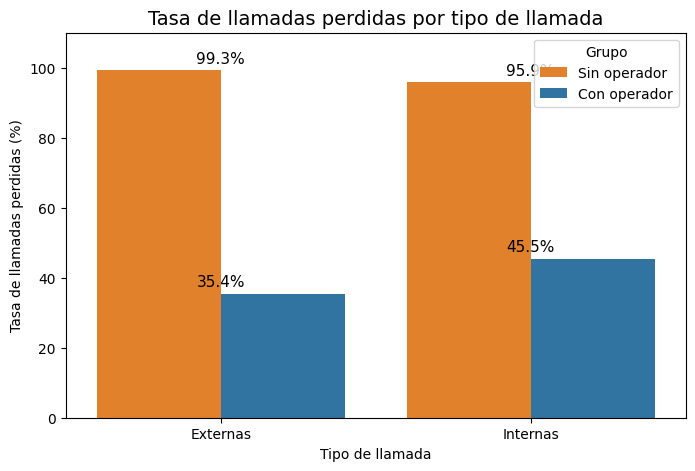

In [631]:
# Gráfico tasa de llamadas perdidas internas y externas

# Crear DataFrame para graficar desde el groupby actualizado
df_plot = pd.DataFrame({
    'internal': ['Externas', 'Internas', 'Externas', 'Internas'],
    'tasa_perdidas': [
        tasa_internal['Sin operador', 'Externa'], 
        tasa_internal['Sin operador', 'Interna'],
        tasa_internal['Con operador', 'Externa'], 
        tasa_internal['Con operador', 'Interna']
    ],
    'grupo': ['Sin operador', 'Sin operador', 'Con operador', 'Con operador']
})

# Crear figura
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_plot, 
    x='internal', 
    y='tasa_perdidas', 
    hue='grupo', 
    palette=['#ff7f0e', '#1f77b4']
)

# Etiquetas y título
plt.title("Tasa de llamadas perdidas por tipo de llamada", fontsize=14)
plt.ylabel("Tasa de llamadas perdidas (%)")
plt.xlabel("Tipo de llamada")
plt.ylim(0, 110)

# Mostrar valor encima de cada barra
for i, row in df_plot.iterrows():
    plt.text(
        x=i%2,  # posicion x: 0 para Externas, 1 para Internas
        y=row['tasa_perdidas'] + 2, 
        s=f"{row['tasa_perdidas']:.1f}%", 
        ha='center', 
        fontsize=11
    )

plt.legend(title='Grupo')
plt.show()

In [632]:
#d.  Duración mediana por llamadas internas/externas
avg_time_internal = (
    tipicos.groupby('internal')['call_duration_min']
    .median()
    .round(2)
    .reset_index()
    .rename(columns={'internal': 'tipo_llamada', 'call_duration_min': 'duracion_mediana'})
)

# Mapear True/False a etiquetas claras
avg_time_internal['tipo_llamada'] = avg_time_internal['tipo_llamada'].map({True: 'Internas', False: 'Externas'})

print("\nDuración promedio (mediana) por llamadas internas/externas:\n", avg_time_internal)


Duración promedio (mediana) por llamadas internas/externas:
   tipo_llamada  duracion_mediana
0     Externas              0.25
1     Internas              0.10


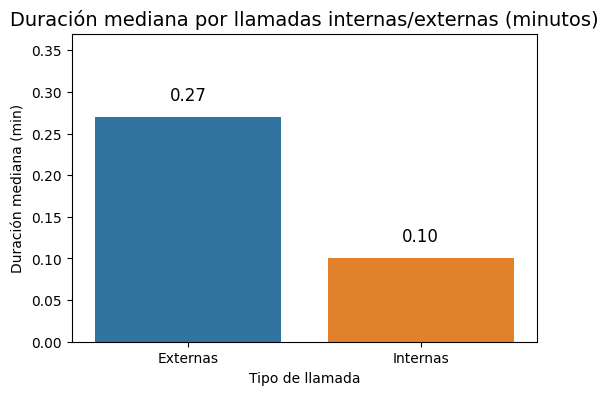

In [633]:
# duración mediana por llamdas internas y externas
# Datos
df_duration_internal = pd.DataFrame({
    'tipo_llamada': ['Externas', 'Internas'],
    'duracion_mediana': [0.27, 0.10]
})

# Crear figura
plt.figure(figsize=(6,4))
sns.barplot(data=df_duration_internal, x='tipo_llamada', y='duracion_mediana', hue='tipo_llamada',
            dodge=False, palette=['#1f77b4', '#ff7f0e'], legend=False)

# Etiquetas
plt.title("Duración mediana por llamadas internas/externas (minutos)", fontsize=14)
plt.xlabel("Tipo de llamada")
plt.ylabel("Duración mediana (min)")
plt.ylim(0, max(df_duration_internal['duracion_mediana']) + 0.1)

# Mostrar valor encima de cada barra
for i, val in enumerate(df_duration_internal['duracion_mediana']):
    plt.text(i, val + 0.02, f"{val:.2f}", ha='center', fontsize=12)

plt.show()

4.3 Primer insight de ineficiencia

las llamadas salientes representan un punto crítico de ineficiencia dentro de la operación, constituyéndose como una prioridad para análisis posteriores orientados a identificar causas raíz y definir acciones de mejora.


4.4 Análisis por operador

In [634]:
# Confirmo la cantidad de operadores analizados

print("Operadores únicos:", tipicos['operator_id'].nunique())

Operadores únicos: 1081


In [635]:
# Revisión inicial de infeff_score 

print(tipicos['ineff_score'].describe())
print(tipicos['ineff_score'].value_counts())

count    39289.000000
mean         4.137876
std          1.298035
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          8.000000
Name: ineff_score, dtype: float64
ineff_score
4    10963
3     9501
6     7582
5     6852
2     3878
7      344
1      150
8       19
Name: count, dtype: int64


a. Análisis de productividad y eficiencia general por operador

In [636]:
# =========================================
# 1️⃣ Semáforo dinámico para ineff_score_mean (incluye wait_time)
# =========================================

# Calcular percentiles dinámicos
q25 = operador_summary_tipicos['ineff_score_mean'].quantile(0.25)
q50 = operador_summary_tipicos['ineff_score_mean'].quantile(0.50)
q75 = operador_summary_tipicos['ineff_score_mean'].quantile(0.75)

# Función de semáforo ajustada
def sem_ineff_dynamic(x):
    if x > q75:
        return '🔴 Crítico'
    elif x > q50:
        return '🟠 Riesgo medio'
    elif x > q25:
        return '🟡 Alerta leve'
    else:
        return '🟢 Excelente'

# Aplicar semáforo a cada operador
operador_summary_tipicos['ineff_score_semaforo'] = operador_summary_tipicos['ineff_score_mean'].apply(sem_ineff_dynamic)

# =========================================
# 2️⃣ Ranking de operadores por ineff_score
# =========================================
ranking_operadores = operador_summary_tipicos.sort_values(
    'ineff_score_mean', ascending=False
)[['operator_id', 'ineff_score_mean', 'ineff_score_semaforo', 
   'missed_call_rate', 'avg_wait_time', 'total_calls', 'total_duration']]

# Mostrar top 10 operadores más ineficientes
print("\n📋 Top 10 operadores más ineficientes:\n")
display(ranking_operadores.head(10))

# =========================================
# 3️⃣ Conteo y porcentaje de operadores por semáforo
# =========================================
conteo_semaforo = operador_summary_tipicos['ineff_score_semaforo'].value_counts().reset_index()
conteo_semaforo.columns = ['Nivel semáforo', 'Cantidad de operadores']

# Calcular porcentaje
total_ops = operador_summary_tipicos.shape[0]
conteo_semaforo['Porcentaje'] = (conteo_semaforo['Cantidad de operadores'] / total_ops * 100).round(1)

# Ordenar semáforo de crítico a excelente
orden = ['🔴 Crítico', '🟠 Riesgo medio', '🟡 Alerta leve', '🟢 Excelente']
conteo_semaforo['Nivel semáforo'] = pd.Categorical(conteo_semaforo['Nivel semáforo'], categories=orden, ordered=True)
conteo_semaforo = conteo_semaforo.sort_values('Nivel semáforo')

print("\n📊 Cantidad y porcentaje de operadores por nivel de semáforo:\n")
display(conteo_semaforo)


📋 Top 10 operadores más ineficientes:



,operator_id,ineff_score_mean,ineff_score_semaforo,missed_call_rate,avg_wait_time,total_calls,total_duration
935,952292,7.0,🔴 Crítico,0.0,1.350000,1,8.866667
457,919504,6.0,🔴 Crítico,1.0,14.750000,1,14.750000
497,921596,6.0,🔴 Crítico,1.0,11.600000,2,23.200000
446,919370,6.0,🔴 Crítico,1.0,10.516667,1,10.516667
496,921592,6.0,🔴 Crítico,1.0,13.350000,1,13.350000
494,921574,6.0,🔴 Crítico,1.0,9.383333,1,9.383333
74,891192,6.0,🔴 Crítico,0.0,0.533333,1,22.300000
413,917890,6.0,🔴 Crítico,0.0,0.216667,1,11.000000
509,922710,6.0,🔴 Crítico,1.0,10.716667,1,10.716667
807,943050,6.0,🔴 Crítico,0.0,2.783333,1,19.216667



📊 Cantidad y porcentaje de operadores por nivel de semáforo:



,Nivel semáforo,Cantidad de operadores,Porcentaje
2,🔴 Crítico,270,25.0
3,🟠 Riesgo medio,258,23.9
0,🟡 Alerta leve,282,26.1
1,🟢 Excelente,271,25.1


c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


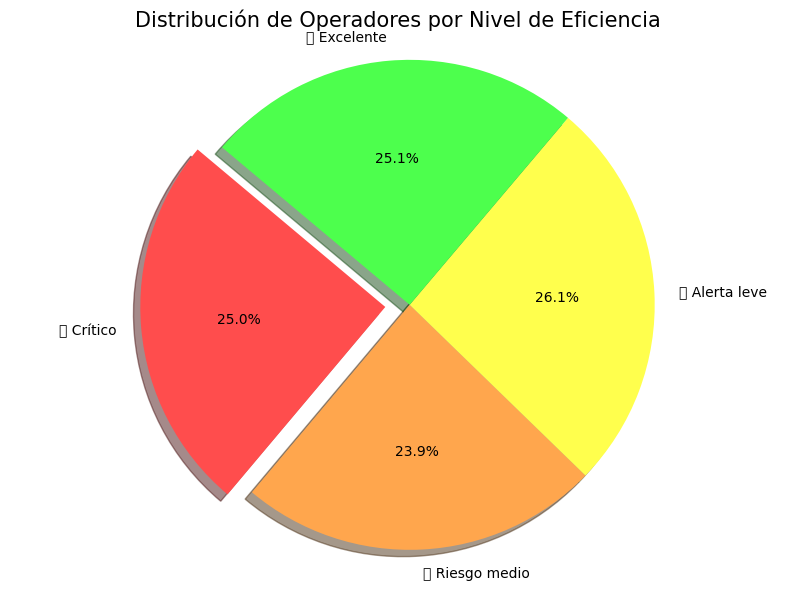

In [637]:

# Gráfico del sémafor0

# Aseguramos que los colores coincidan con los niveles
colores = ['#ff4d4d', '#ffa64d', '#ffff4d', '#4dff4d'] # Rojo, Naranja, Amarillo, Verde

plt.figure(figsize=(10, 7))

# 2. Crear el gráfico de torta
plt.pie(
    conteo_semaforo['Cantidad de operadores'], 
    labels=conteo_semaforo['Nivel semáforo'],
    autopct='%1.1f%%', 
    startangle=140,
    colors=colores,
    explode=(0.1, 0, 0, 0), # Resaltamos el grupo 'Crítico'
    shadow=True
)

plt.title('Distribución de Operadores por Nivel de Eficiencia', fontsize=15)
plt.axis('equal')  # Para que el círculo sea perfecto

plt.show()

In [638]:
#a. Tasa de llamadas perdidas
lost_rate_operator = tipicos.groupby('operator_id')['is_missed_call'].mean()
lost_rate_operator.sort_values(ascending=False).head(10)

operator_id
969284    1.0
969262    1.0
914626    1.0
914272    1.0
885682    1.0
965544    1.0
919202    1.0
919200    1.0
919198    1.0
941826    1.0
Name: is_missed_call, dtype: float64

In [639]:
# 
# 1️⃣ Calcular duración promedio por operador
avg_duration_operator = tipicos.groupby('operator_id')['call_duration_min'].mean()

# 2️⃣ Calcular duración promedio general (mediana de promedios)
avg_duration_general = avg_duration_operator.median()

# 3️⃣ Mostrar resultado
print("Duración promedio general por operador (min):", round(avg_duration_general, 2))

Duración promedio general por operador (min): 2.44


Sección Outliers: 

Teniendo en cuenta que el objetivo del proyecto es identificar operadores ineficientes de la compañía, se incluye un análisis menos detallado para los otliers en donde operadores tuvieron participación.

In [640]:
    # Trabajaremos solo con los outliers con operador
    outliers_operador = outliers_con_operador.copy()

    # Total de llamadas por operador
    total_llamadas = telecom_full[telecom_full['operator_id'].notnull()].groupby('operator_id').size()

    # Cantidad de outliers por operador
    outliers_count = outliers_operador.groupby('operator_id').size()

    # Proporción de outliers sobre total de llamadas del operador
    outliers_pct = outliers_count / total_llamadas * 100

In [641]:


# -----------------------------
# Solo outliers con operador
# -----------------------------
outliers_operador = outliers_con_operador.copy()

# -----------------------------
# Cantidad de outliers por operador
# -----------------------------
outliers_count = outliers_operador.groupby('operator_id').size()

# -----------------------------
# Total de llamadas por operador
# -----------------------------
total_llamadas = telecom_full[
    telecom_full['operator_id'].notnull()
].groupby('operator_id').size()

# -----------------------------
# Proporción de outliers
# -----------------------------
outliers_pct = (outliers_count / total_llamadas * 100).fillna(0)

# -----------------------------
# Z-scores de variables (magnitud)
# -----------------------------
outliers_operador['call_duration_z'] = zscore(outliers_operador['call_duration_min'])
outliers_operador['total_duration_z'] = zscore(outliers_operador['total_call_duration_min'])

# Promedio de magnitud por operador
magnitud_score = (
    outliers_operador
    .groupby('operator_id')[['call_duration_z','total_duration_z']]
    .mean()
    .mean(axis=1)
)

# -----------------------------
# NORMALIZAR variables (clave 🔥)
# -----------------------------
outliers_count_z = pd.Series(zscore(outliers_count), index=outliers_count.index)
outliers_pct_z = pd.Series(zscore(outliers_pct), index=outliers_pct.index)

# Alinear magnitud
magnitud_score = magnitud_score.reindex(outliers_count.index).fillna(0)

# -----------------------------
# Score final balanceado
# -----------------------------
score_ineficiencia = (
    0.5 * outliers_count_z +
    0.3 * outliers_pct_z +
    0.2 * magnitud_score
).sort_values(ascending=False)

# -----------------------------
# Crear DataFrame final
# -----------------------------
score_df = pd.DataFrame({
    'operator_id': score_ineficiencia.index,
    'score_ineficiencia': score_ineficiencia.values,
    'outliers_count': outliers_count.reindex(score_ineficiencia.index, fill_value=0),
    'outliers_pct': outliers_pct.reindex(score_ineficiencia.index, fill_value=0)
})

# -----------------------------
# Mapear score a niveles (1–5) usando percentiles
# -----------------------------
percentiles = score_df['score_ineficiencia'].quantile([0.2,0.4,0.6,0.8]).values

def map_score_tipicos_percentil(score):
    if score <= percentiles[0]:
        return 1  # Muy eficiente
    elif score <= percentiles[1]:
        return 2  # Eficiente
    elif score <= percentiles[2]:
        return 3  # Regular
    elif score <= percentiles[3]:
        return 4  # Ineficiente
    else:
        return 5  # Muy ineficiente

# Aplicar mapeo
score_df['score_tipicos'] = score_df['score_ineficiencia'].apply(map_score_tipicos_percentil)

# -----------------------------
# Ordenar resultados
# -----------------------------
score_df = score_df.sort_values(by='score_ineficiencia', ascending=False)

# -----------------------------
# (NUEVO) Totales y porcentaje por nivel
# -----------------------------
total_operadores = len(score_df)

resumen_niveles = score_df.groupby('score_tipicos').agg({
    'operator_id': 'count',
    'outliers_count': 'sum',
    'outliers_pct': 'mean'
}).rename(columns={'operator_id': 'total_operadores'})

resumen_niveles['porcentaje_operadores'] = (
    resumen_niveles['total_operadores'] / total_operadores * 100
)

resumen_niveles = resumen_niveles.sort_index()

# -----------------------------
# Outputs
# -----------------------------
print("Top 10 operadores más ineficientes:")
display(score_df.head(10))

print("\nResumen por niveles:")
display(resumen_niveles)

Top 10 operadores más ineficientes:


,operator_id,score_ineficiencia,outliers_count,outliers_pct,score_tipicos
operator_id,,,,,
901880,901880,4.001185,135,44.701987,5
885876,885876,3.737522,100,35.335689,5
885890,885890,3.575350,99,39.130435,5
890406,890406,3.158635,103,47.685185,5
891410,891410,2.798682,97,37.164751,5
890404,890404,2.745565,93,40.434783,5
890402,890402,2.740629,92,41.818182,5
882686,882686,2.566086,87,38.839286,5
893804,893804,2.546403,92,31.833910,5



Resumen por niveles:


,total_operadores,outliers_count,outliers_pct,porcentaje_operadores
score_tipicos,,,,
1,104,164,3.113761,9.52381
2,104,412,9.744710,9.52381
3,103,839,20.989055,9.432234
4,104,1387,37.093685,9.52381
5,677,4010,6.475642,61.996337


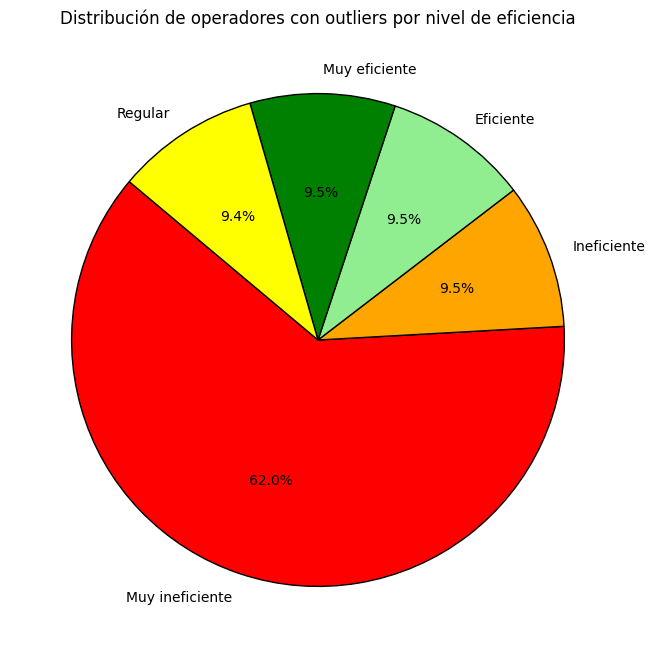

In [642]:

# Contar operadores por nivel de eficiencia

# Mapear score_tipicos (1–5) a etiquetas de eficiencia
map_niveles = {
    1: 'Muy eficiente',
    2: 'Eficiente',
    3: 'Regular',
    4: 'Ineficiente',
    5: 'Muy ineficiente'
}

score_df['nivel_eficiencia'] = score_df['score_tipicos'].map(map_niveles)

# Contar operadores por nivel
niveles_count = score_df['nivel_eficiencia'].value_counts()

# Colores para cada nivel
colores = {
    'Muy eficiente':'green',
    'Eficiente':'lightgreen',
    'Regular':'yellow',
    'Ineficiente':'orange',
    'Muy ineficiente':'red'
}

# Gráfico de torta
plt.figure(figsize=(8,8))
plt.pie(
    niveles_count,
    labels=niveles_count.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=[colores[n] for n in niveles_count.index],
    wedgeprops={'edgecolor':'black'}
)
plt.title('Distribución de operadores con outliers por nivel de eficiencia')
plt.show()

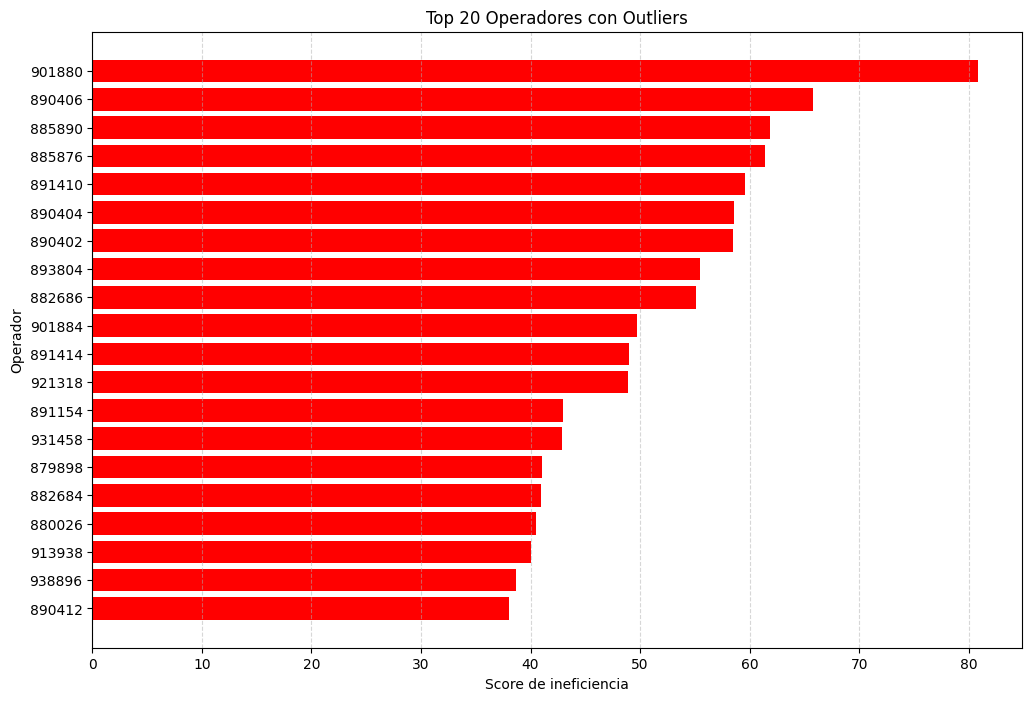

In [643]:


# -----------------------------
# Solo operadores con outliers
# -----------------------------
outliers_operador = outliers_con_operador.copy()

# Contar cantidad de outliers por operador
outliers_count = outliers_operador.groupby('operator_id').size()

# Total de llamadas por operador
total_llamadas = telecom_full[telecom_full['operator_id'].notnull()].groupby('operator_id').size()

# Proporción de outliers
outliers_pct = (outliers_count / total_llamadas * 100).fillna(0)

# Calcular z-scores de las variables disponibles
outliers_operador['call_duration_z'] = zscore(outliers_operador['call_duration_min'])
outliers_operador['total_duration_z'] = zscore(outliers_operador['total_call_duration_min'])

# Promedio de magnitud de z-scores por operador
magnitud_score = (
    outliers_operador
    .groupby('operator_id')[['call_duration_z','total_duration_z']]
    .mean()
    .mean(axis=1)
)

# Score final para outliers
score_ineficiencia = (0.5 * outliers_count + 0.3 * outliers_pct + 0.2 * magnitud_score).sort_values(ascending=False)

# Crear DataFrame final
score_df = pd.DataFrame({
    'operator_id': score_ineficiencia.index,
    'score_ineficiencia': score_ineficiencia.values,
    'outliers_count': outliers_count.reindex(score_ineficiencia.index, fill_value=0),
    'outliers_pct': outliers_pct.reindex(score_ineficiencia.index, fill_value=0)
})

# -----------------------------
# Nivel de eficiencia (terciles)
# -----------------------------
def eficiencia_label(score):
    if score < score_df['score_ineficiencia'].quantile(0.33):
        return 'Regular'
    elif score < score_df['score_ineficiencia'].quantile(0.66):
        return 'Ineficiente'
    else:
        return 'Muy ineficiente'

score_df['nivel_eficiencia'] = score_df['score_ineficiencia'].apply(eficiencia_label)

# -----------------------------
# Gráfico top 20 operadores con outliers
# -----------------------------
top20 = score_df.head(20).sort_values('score_ineficiencia', ascending=True)

plt.figure(figsize=(12,8))
colors = top20['nivel_eficiencia'].map({'Regular':'yellow','Ineficiente':'orange','Muy ineficiente':'red'})
plt.barh(top20['operator_id'].astype(str), top20['score_ineficiencia'], color=colors)
plt.xlabel('Score de ineficiencia')
plt.ylabel('Operador')
plt.title('Top 20 Operadores con Outliers')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

In [644]:
# Identificamos operadores que están en ambos conjuntos
duplicados = tipicos.index.intersection(outliers.index)

# Cantidad de operadores repetidos
print("Cantidad de operadores que aparecen en ambos conjuntos:", len(duplicados))

# Si quieres ver quiénes son
print(duplicados)

Cantidad de operadores que aparecen en ambos conjuntos: 0
Index([], dtype='int64')


4.5 Segmentación 

remitirse al Semáforo de niveles de productividad y cumplimiento por operador en donde se muestra la clasificación por niveles de eficiencia.

4.6 Identificación de patrones

4.7 Cruces operador - cliente


C:\Users\mateg\AppData\Local\Temp\ipykernel_19592\1354490145.py:26: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mateg\AppData\Local\Temp\ipykernel_19592\1354490145.py:26: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mateg\AppData\Local\Temp\ipykernel_19592\1354490145.py:26: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\mateg\AppData\Local\Temp\ipykernel_19592\1354490145.py:26: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\mateg\AppData\Local\Programs\Python\Python311\Lib\site-package

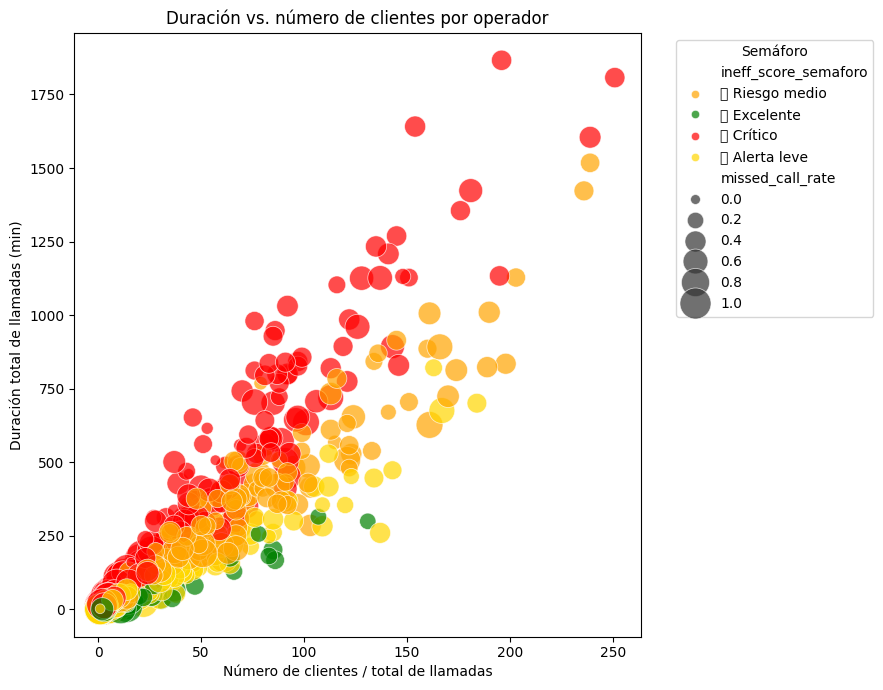

In [645]:

# Mapear colores del semáforo dinámico
color_map = {
    '🔴 Crítico': 'red',
    '🟠 Riesgo medio': 'orange',
    '🟡 Alerta leve': 'gold',
    '🟢 Excelente': 'green'
}

plt.figure(figsize=(9,7))

sns.scatterplot(
    data=operador_summary_tipicos,
    x='total_calls',                # número de clientes/llamadas por operador
    y='total_duration',             # duración promedio o total de llamadas
    size='missed_call_rate',        # tamaño del punto según llamadas perdidas
    hue='ineff_score_semaforo',     # color según semáforo dinámico
    palette=color_map,
    sizes=(50, 500),
    alpha=0.7
)

plt.title("Duración vs. número de clientes por operador")
plt.xlabel("Número de clientes / total de llamadas")
plt.ylabel("Duración total de llamadas (min)")
plt.legend(title='Semáforo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Paso 5 Análisis de Negocio

5.1 Detectar factores que influyen en el comportamiento del cliente

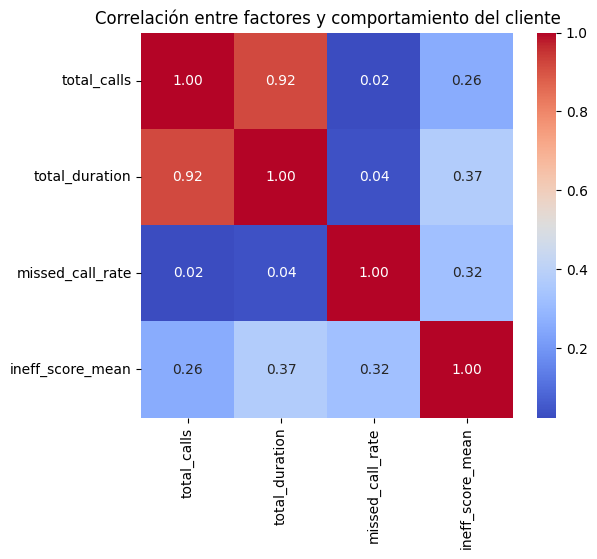

In [646]:

# Seleccionar variables relevantes que sí están en tu DataFrame
vars_corr = operador_summary_tipicos[['total_calls','total_duration','missed_call_rate','ineff_score_mean']]

# Matriz de correlación
corr = vars_corr.corr()

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre factores y comportamiento del cliente")
plt.show()

5.3 Prueba de hipótesis

In [647]:
# Prueba z-test de proporciones

# Conteos
missed_in = tipicos[tipicos['direction'] == 'in']['is_missed_call'].sum()
total_in = tipicos[tipicos['direction'] == 'in']['is_missed_call'].count()

missed_out = tipicos[tipicos['direction'] == 'out']['is_missed_call'].sum()
total_out = tipicos[tipicos['direction'] == 'out']['is_missed_call'].count()

# Datos para la prueba
count = [missed_out, missed_in]
nobs = [total_out, total_in]

# Test (one-sided: out > in)
stat, pval = proportions_ztest(count, nobs, alternative='larger')

print(f"Z-stat: {stat:.3f}, p-value: {pval:.5f}")

if pval < 0.05:
    print("✅ Las llamadas salientes tienen una tasa de pérdida significativamente mayor")
else:
    print("❌ No hay evidencia suficiente de diferencia significativa")

Z-stat: 21.433, p-value: 0.00000
✅ Las llamadas salientes tienen una tasa de pérdida significativamente mayor
